In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
# Configuration dynamique
DATA_DIR = Path('capture/train_data/Prise mouvement')
movement_dirs = sorted(
    [d for d in DATA_DIR.iterdir() if d.is_dir() and d.name.startswith('mouvement_')],
    key=lambda d: int(d.name.split('_')[1]),
)
NUM_CLASSES = len(movement_dirs)


In [3]:
# Charger les données
X_data = []
y_data = []

for movement_dir in movement_dirs:
    label = int(movement_dir.name.split('_')[1]) - 1  # 0-indexé
    npy_files = sorted(movement_dir.glob(f"{movement_dir.name}_*.npy"))
    for f in npy_files:
        X_data.append(np.load(f))
        y_data.append(label)

print(f"{NUM_CLASSES} mouvements | {len(X_data)} séquences")

22 mouvements | 857 séquences


In [4]:
import os

# Labels auto-détectés depuis les noms de dossiers
labels = [d.name for d in movement_dirs]

print(f"Classes: {NUM_CLASSES}")

Classes: 22


In [5]:
label_map = {label:num for num, label in enumerate(labels)}

In [6]:
label_map

{'mouvement_1': 0,
 'mouvement_2': 1,
 'mouvement_3': 2,
 'mouvement_4': 3,
 'mouvement_5': 4,
 'mouvement_6': 5,
 'mouvement_7': 6,
 'mouvement_8': 7,
 'mouvement_9': 8,
 'mouvement_10': 9,
 'mouvement_11': 10,
 'mouvement_12': 11,
 'mouvement_13': 12,
 'mouvement_14': 13,
 'mouvement_15': 14,
 'mouvement_16': 15,
 'mouvement_17': 16,
 'mouvement_18': 17,
 'mouvement_19': 18,
 'mouvement_20': 19,
 'mouvement_21': 20,
 'mouvement_22': 21}

In [7]:
MAX_LEN = 60

X_padded = pad_sequences(
    X_data,
    maxlen=MAX_LEN,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0,
)

# Normalisation : mean=0, std=1
mean = X_padded[X_padded != 0.0].mean()
std = X_padded[X_padded != 0.0].std()
X_padded = np.where(X_padded != 0.0, (X_padded - mean) / std, 0.0)

print(f"Shape: {X_padded.shape}, Mean: {X_padded[X_padded != 0.0].mean():.4f}, Std: {X_padded[X_padded != 0.0].std():.4f}")

Shape: (857, 60, 282), Mean: 0.0000, Std: 1.0000


In [8]:
len(X_padded)

857

In [9]:
y = to_categorical(y_data, num_classes=NUM_CLASSES).astype(int)
y

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 1, 0]])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y,
    test_size=0.2,
    stratify=y_data,
    random_state=69,
)


In [13]:
y_train.shape

X_train.shape

(685, 60, 282)

In [14]:
# Neural Network Architecture
model = Sequential()
model.add(layers.Input(shape=(60, 282)))
model.add(layers.LSTM(64, return_sequences=True))
model.add(layers.LSTM(64, return_sequences=False))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        88,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,662 (486.96 KB)

 Trainable params: 124,662 (486.96 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.0496 - loss: 3.0990 - val_accuracy: 0.0930 - val_loss: 3.0629 - learning_rate: 5.0000e-04
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.0613 - loss: 3.0660 - val_accuracy: 0.0988 - val_loss: 3.0257 - learning_rate: 5.0000e-04
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.0920 - loss: 3.0176 - val_accuracy: 0.1570 - val_loss: 2.9687 - learning_rate: 5.0000e-04
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.1139 - loss: 2.9766 - val_accuracy: 0.1163 - val_loss: 2.8951 - learning_rate: 5.0000e-04
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.1372 - loss: 2.8924 - val_accuracy: 0.1047 - val_loss: 2.8630 - learning_rate: 5.0000e-04
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.1299 - loss: 2.8481 - val_accuracy: 0.1860 - val_loss: 2.7083 - learning_rate: 5.0000e-04
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 

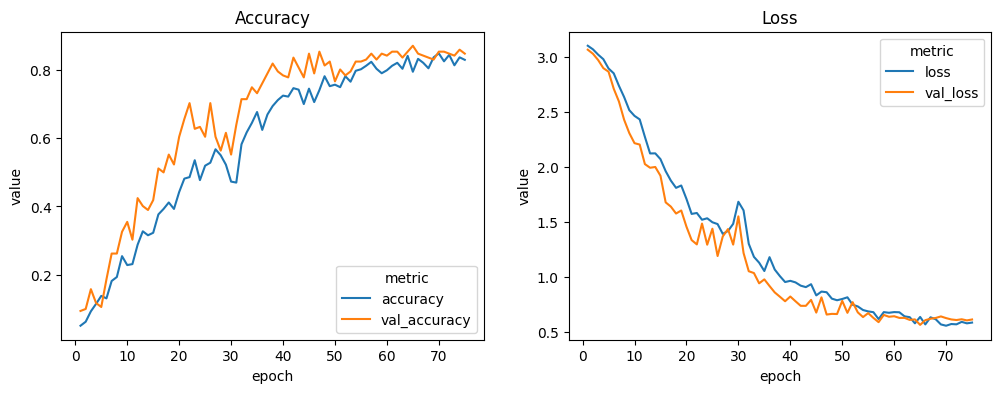

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt


df_hist = pd.DataFrame(history.history)
df_hist['epoch'] = range(1, len(df_hist) + 1)
df_hist = df_hist.melt(id_vars='epoch', var_name='metric', value_name='value')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=df_hist[df_hist['metric'].str.contains('accuracy')], x='epoch', y='value', hue='metric', ax=ax1)
ax1.set_title('Accuracy')

sns.lineplot(data=df_hist[df_hist['metric'].str.contains('loss')], x='epoch', y='value', hue='metric', ax=ax2)
ax2.set_title('Loss')

plt.show()

## Analyse de features

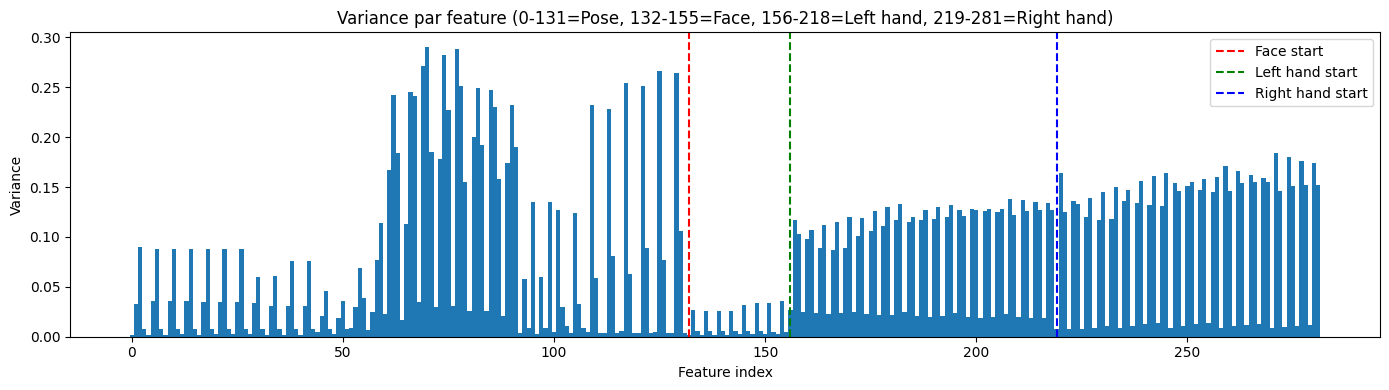

Features quasi constantes (var < 0.01) : 72 / 282
Indices : [  0   3   4   7   8  11  12  15  16  19  20  23  24  27  28  31  32  35
  36  39  40  43  44  47  48  51  52  56  92  94  96  98 100 104 107 108
 111 112 115 116 119 120 123 124 127 128 131 132 134 135 137 138 140 141
 143 144 146 147 149 150 152 153 155 219 222 225 228 234 246 258 270 273]


In [18]:
# Variance par feature sur l'ensemble du dataset
var_per_feature = X_padded.reshape(-1, 282).var(axis=0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(282), var_per_feature, width=1)
ax.axvline(132, color='r', linestyle='--', label='Face start')
ax.axvline(156, color='g', linestyle='--', label='Left hand start')
ax.axvline(219, color='b', linestyle='--', label='Right hand start')
ax.set_title('Variance par feature (0-131=Pose, 132-155=Face, 156-218=Left hand, 219-281=Right hand)')
ax.set_xlabel('Feature index')
ax.set_ylabel('Variance')
ax.legend()
plt.tight_layout()
plt.show()

# Features avec variance quasi nulle (inutiles)
low_var = np.where(var_per_feature < 0.01)[0]
print(f"Features quasi constantes (var < 0.01) : {len(low_var)} / 282")
print(f"Indices : {low_var}")

Text(0.5, 1.0, 'Corrélation entre groupes de features')

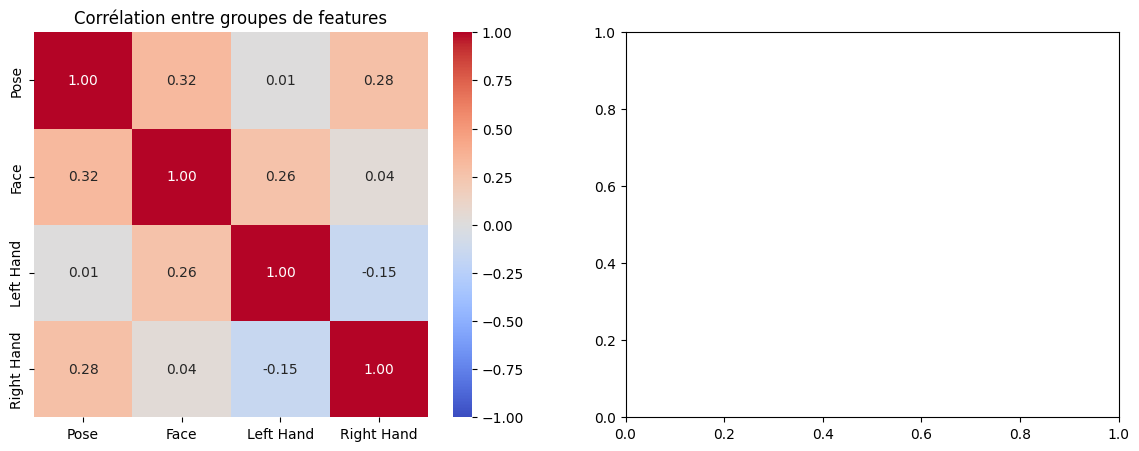

In [19]:
# Heatmap des corrélations entre les 4 groupes de features
import matplotlib.pyplot as plt

pose = X_padded[:, :, :132].reshape(len(X_padded), -1)
face = X_padded[:, :, 132:156].reshape(len(X_padded), -1)
left_hand = X_padded[:, :, 156:219].reshape(len(X_padded), -1)
right_hand = X_padded[:, :, 219:282].reshape(len(X_padded), -1)

groups = {
    'Pose': pose,
    'Face': face,
    'Left Hand': left_hand,
    'Right Hand': right_hand,
}

# Matrice de corrélation entre groupes
corr_matrix = pd.DataFrame({
    name: {other: np.corrcoef(g1.mean(axis=1), g2.mean(axis=1))[0, 1]
           for other, g2 in groups.items()}
    for name, g1 in groups.items()
}).astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax1,
            vmin=-1, vmax=1, fmt='.2f')
ax1.set_title('Corrélation entre groupes de features')


In [20]:
# Retirer les features constantes
var_per_feature = X_padded.reshape(-1, 282).var(axis=0)
useful_mask = var_per_feature >= 0.01

print(f"Features utiles : {useful_mask.sum()} / 282")
print(f"Features retirées : {(~useful_mask).sum()}")

# Filtrer
X_clean = X_padded[:, :, useful_mask]
print(f"Nouvelle shape : {X_clean.shape}")

Features utiles : 210 / 282
Features retirées : 72
Nouvelle shape : (857, 60, 210)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    stratify=y_data,
    random_state=69,
)

In [22]:
model = Sequential()
model.add(layers.Input(shape=X_train.shape[1:]))
model.add(layers.LSTM(64, return_sequences=True))
model.add(layers.LSTM(64, return_sequences=False))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        70,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,230 (414.96 KB)

 Trainable params: 106,230 (414.96 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.0511 - loss: 3.0890 - val_accuracy: 0.0988 - val_loss: 3.0455 - learning_rate: 5.0000e-04
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.0774 - loss: 3.0389 - val_accuracy: 0.0872 - val_loss: 2.9876 - learning_rate: 5.0000e-04
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.0861 - loss: 2.9804 - val_accuracy: 0.0988 - val_loss: 2.9070 - learning_rate: 5.0000e-04
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1182 - loss: 2.8837 - val_accuracy: 0.1337 - val_loss: 2.7821 - learning_rate: 5.0000e-04
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1489 - loss: 2.8364 - val_accuracy: 0.1919 - val_loss: 2.6923 - learning_rate: 5.0000e-04
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.1708 - loss: 2.7545 - val_accuracy: 0.2093 - val_loss: 2.6052 - learning_rate: 5.0000e-04
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 

## Data Augmentation


In [24]:
def augment_mirror(X, y):
    """Double le dataset par miroir horizontal (gauche↔droite)."""
    structure = {
        'pose':       (33, 4),  # x,y,z,visibility
        'face':       (8,  3),  # x,y,z
        'left_hand':  (21, 3),  # x,y,z
        'right_hand': (21, 3),  # x,y,z
    }

    slices = {}
    offset = 0
    for name, (count, dims) in structure.items():
        size = count * dims
        slices[name] = (slice(offset, offset + size), count, dims)
        offset += size

    x_indices = []
    for name, (slc, count, dims) in slices.items():
        x_indices.extend(range(slc.start, slc.stop, dims))

    X_mirror = X.copy()

    # Inverser l'axe x
    X_mirror[:, :, x_indices] = 1.0 - X_mirror[:, :, x_indices]

    # Échanger main gauche ↔ droite
    lh = slices['left_hand'][0]
    rh = slices['right_hand'][0]
    X_mirror[:, :, lh], X_mirror[:, :, rh] = (
        X_mirror[:, :, rh].copy(),
        X_mirror[:, :, lh].copy(),
    )

    # Échanger pose gauche ↔ droite (indices 11-32, pairs=gauche, impairs=droite)
    pose_slc, _, pose_dims = slices['pose']
    for i in range(11, 33, 2):
        l = slice(pose_slc.start + i * pose_dims, pose_slc.start + (i+1) * pose_dims)
        r = slice(pose_slc.start + (i+1) * pose_dims, pose_slc.start + (i+2) * pose_dims)
        X_mirror[:, :, l], X_mirror[:, :, r] = (
            X_mirror[:, :, r].copy(),
            X_mirror[:, :, l].copy(),
        )

    X_aug = np.concatenate([X, X_mirror], axis=0)
    y_aug = np.concatenate([y, y], axis=0)

    print(f"Avant: {len(X)} | Après: {len(X_aug)}")
    return X_aug, y_aug

In [25]:
y = to_categorical(y_data, num_classes=NUM_CLASSES).astype(int)
X_aug, y_aug = augment_mirror(X_padded, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug,
    test_size=0.2,
    stratify=np.argmax(y_aug, axis=1),
    random_state=69,
)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Classes: {NUM_CLASSES} | Features: {X_aug.shape[2]}")

Avant: 857 | Après: 1714
Train: 1371 | Test: 343 | Classes: 22 | Features: 282


In [26]:
model_aug = Sequential()
model_aug.add(layers.Input(shape=X_train.shape[1:]))
model_aug.add(layers.LSTM(64, return_sequences=True))
model_aug.add(layers.LSTM(64, return_sequences=False))
model_aug.add(layers.Dropout(0.3))
model_aug.add(layers.Dense(32, activation='relu'))
model_aug.add(layers.Dropout(0.3))
model_aug.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        88,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,662 (486.96 KB)

 Trainable params: 124,662 (486.96 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history = model_aug.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.0518 - loss: 3.0756 - val_accuracy: 0.0962 - val_loss: 3.0370 - learning_rate: 5.0000e-04
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.0890 - loss: 3.0192 - val_accuracy: 0.1079 - val_loss: 2.9559 - learning_rate: 5.0000e-04
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1087 - loss: 2.9336 - val_accuracy: 0.1166 - val_loss: 2.8351 - learning_rate: 5.0000e-04
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.1043 - loss: 2.8479 - val_accuracy: 0.1691 - val_loss: 2.7253 - learning_rate: 5.0000e-04
Epoch 5/100
34/43 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1273 - loss: 2.7936

KeyboardInterrupt: 

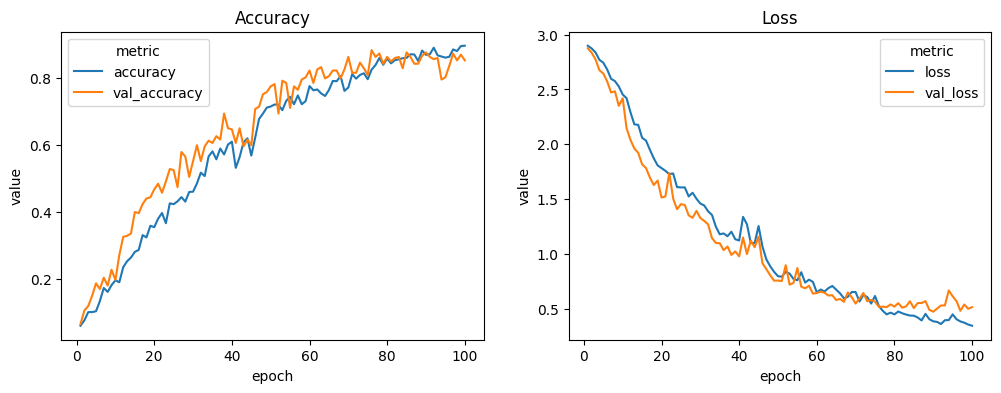

In [ ]:
df_hist = pd.DataFrame(history.history)
df_hist['epoch'] = range(1, len(df_hist) + 1)
df_hist = df_hist.melt(id_vars='epoch', var_name='metric', value_name='value')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=df_hist[df_hist['metric'].str.contains('accuracy')], x='epoch', y='value', hue='metric', ax=ax1)
ax1.set_title('Accuracy')

sns.lineplot(data=df_hist[df_hist['metric'].str.contains('loss')], x='epoch', y='value', hue='metric', ax=ax2)
ax2.set_title('Loss')

plt.show()

## Vitesse 


In [ ]:
def add_velocity(X):
    """Ajoute les features de vitesse (différence frame-to-frame)."""
    velocity = np.zeros_like(X)
    velocity[:, 1:, :] = X[:, 1:, :] - X[:, :-1, :]

    padding_mask = (X == 0.0).all(axis=2, keepdims=True)
    velocity = np.where(padding_mask, 0.0, velocity)

    X_with_vel = np.concatenate([X, velocity], axis=2)
    print(f"Features: {X.shape[2]} → {X_with_vel.shape[2]} (positions + vitesses)")
    return X_with_vel

In [ ]:
X_vel = add_velocity(X_padded)

Features: 282 → 564 (positions + vitesses)


In [ ]:
y = to_categorical(y_data, num_classes=NUM_CLASSES).astype(int)
X_aug, y_aug = augment_mirror(X_vel, y)

Avant: 738 | Après: 1476


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug,
    test_size=0.2,
    stratify=np.argmax(y_aug, axis=1),
    random_state=69,
)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Classes: {NUM_CLASSES}")

Train: 1180 | Test: 296 | Classes: 18


In [ ]:
model = Sequential()
model.add(layers.Input(shape=X_train.shape[1:]))
model.add(layers.LSTM(64, return_sequences=True))
model.add(layers.LSTM(64, return_sequences=False))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.0678 - loss: 2.8969 - val_accuracy: 0.0912 - val_loss: 2.8711 - learning_rate: 5.0000e-04
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.0898 - loss: 2.8720 - val_accuracy: 0.0777 - val_loss: 2.8503 - learning_rate: 5.0000e-04
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.1102 - loss: 2.8057 - val_accuracy: 0.1318 - val_loss: 2.6906 - learning_rate: 5.0000e-04
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.1288 - loss: 2.6943 - val_accuracy: 0.1588 - val_loss: 2.5703 - learning_rate: 5.0000e-04
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.1508 - loss: 2.5809 - val_accuracy: 0.2027 - val_loss: 2.4188 - learning_rate: 5.0000e-04
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.1653 - loss: 2.5187 - val_accuracy: 0.2061 - val_loss: 2.3721 - learning_rate: 5.0000e-04
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 

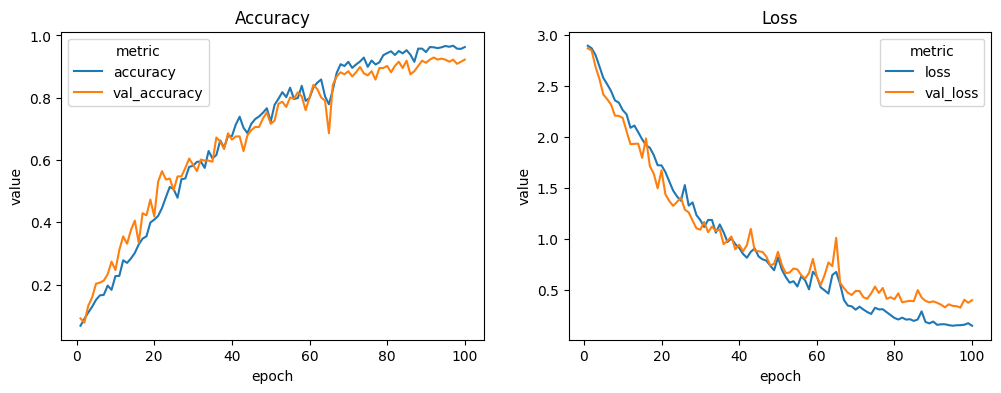

In [ ]:
df_hist = pd.DataFrame(history.history)
df_hist['epoch'] = range(1, len(df_hist) + 1)
df_hist = df_hist.melt(id_vars='epoch', var_name='metric', value_name='value')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=df_hist[df_hist['metric'].str.contains('accuracy')], x='epoch', y='value', hue='metric', ax=ax1)
ax1.set_title('Accuracy')

sns.lineplot(data=df_hist[df_hist['metric'].str.contains('loss')], x='epoch', y='value', hue='metric', ax=ax2)
ax2.set_title('Loss')

plt.show()

## Accélération


In [ ]:
def add_kinematics(X):
    """Ajoute les features de vitesse et d'accélération."""
    # Vitesse : frame[t] - frame[t-1]
    velocity = np.zeros_like(X)
    velocity[:, 1:, :] = X[:, 1:, :] - X[:, :-1, :]

    # Accélération : velocity[t] - velocity[t-1]
    acceleration = np.zeros_like(X)
    acceleration[:, 2:, :] = velocity[:, 2:, :] - velocity[:, 1:-1, :]

    # Zéro sur le padding
    padding_mask = (X == 0.0).all(axis=2, keepdims=True)
    velocity = np.where(padding_mask, 0.0, velocity)
    acceleration = np.where(padding_mask, 0.0, acceleration)

    X_full = np.concatenate([X, velocity, acceleration], axis=2)
    print(f"Features: {X.shape[2]} → {X_full.shape[2]} (positions + vitesses + accélérations)")
    return X_full

In [ ]:
X_kine = add_kinematics(X_padded)

Features: 282 → 846 (positions + vitesses + accélérations)


In [ ]:
y = to_categorical(y_data, num_classes=NUM_CLASSES).astype(int)
X_aug, y_aug = augment_mirror(X_kine, y)

Avant: 738 | Après: 1476


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug,
    test_size=0.2,
    stratify=np.argmax(y_aug, axis=1),
    random_state=69,
)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Classes: {NUM_CLASSES}")

Train: 1180 | Test: 296 | Classes: 18


In [ ]:
model = Sequential()
model.add(layers.Input(shape=X_train.shape[1:]))
model.add(layers.LSTM(64, return_sequences=True))
model.add(layers.LSTM(64, return_sequences=False))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.0619 - loss: 2.8983 - val_accuracy: 0.0980 - val_loss: 2.8702 - learning_rate: 5.0000e-04
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.0653 - loss: 2.8844 - val_accuracy: 0.1486 - val_loss: 2.8400 - learning_rate: 5.0000e-04
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.0814 - loss: 2.8473 - val_accuracy: 0.1453 - val_loss: 2.7902 - learning_rate: 5.0000e-04
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.1186 - loss: 2.7841 - val_accuracy: 0.1926 - val_loss: 2.7018 - learning_rate: 5.0000e-04
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.1305 - loss: 2.7228 - val_accuracy: 0.1453 - val_loss: 2.6377 - learning_rate: 5.0000e-04
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.1492 - loss: 2.6511 - val_accuracy: 0.1892 - val_loss: 2.5364 - learning_rate: 5.0000e-04
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 

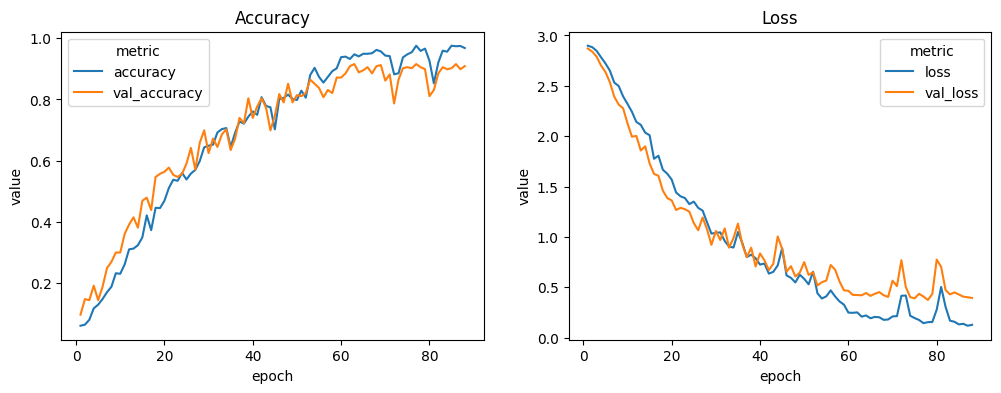

In [ ]:
df_hist = pd.DataFrame(history.history)
df_hist['epoch'] = range(1, len(df_hist) + 1)
df_hist = df_hist.melt(id_vars='epoch', var_name='metric', value_name='value')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=df_hist[df_hist['metric'].str.contains('accuracy')], x='epoch', y='value', hue='metric', ax=ax1)
ax1.set_title('Accuracy')

sns.lineplot(data=df_hist[df_hist['metric'].str.contains('loss')], x='epoch', y='value', hue='metric', ax=ax2)
ax2.set_title('Loss')

plt.show()

## Analyse

In [ ]:
# Détail par bloc : combien de features utiles vs constantes
X_full = add_kinematics(X_padded)  # 846 features
var_all = X_full.reshape(-1, X_full.shape[2]).var(axis=0)

print(f"{'Section':<15} {'Total':>6} {'Utiles':>6} {'Constantes':>10} {'% utile':>8}")
print("-" * 50)

for block_idx, label in [(0, 'Positions'), (1, 'Vitesses'), (2, 'Accélérations')]:
    start = block_idx * 282
    end = start + 282
    total = 282
    constant = np.sum(var_all[start:end] < 0.01)
    useful = total - constant
    pct = useful / total * 100
    print(f"{label:<15} {total:>6} {useful:>6} {constant:>10} {pct:>7.1f}%")

Features: 282 → 846 (positions + vitesses + accélérations)
Section          Total Utiles Constantes  % utile
--------------------------------------------------
Positions          282    202         80    71.6%
Vitesses           282     93        189    33.0%
Accélérations      282    105        177    37.2%


In [ ]:
# Filtrer les features constantes sur les données cinématiques
X_full = add_kinematics(X_padded)
var_all = X_full.reshape(-1, X_full.shape[2]).var(axis=0)
useful_mask = var_all >= 0.01

X_filtered = X_full[:, :, useful_mask]
print(f"846 → {X_filtered.shape[2]} features utiles")

y = to_categorical(y_data, num_classes=NUM_CLASSES).astype(int)
X_aug, y_aug = augment_mirror(X_filtered, y)

X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_aug, y_aug,
    test_size=0.2,
    stratify=np.argmax(y_aug, axis=1),
    random_state=69,
)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {X_filtered.shape[2]}")

Features: 282 → 846 (positions + vitesses + accélérations)
846 → 400 features utiles
Avant: 738 | Après: 1476
Train: 1180 | Test: 296 | Features: 400


In [ ]:
model_filtered = Sequential()
model_filtered.add(layers.Input(shape=X_train.shape[1:]))
model_filtered.add(layers.LSTM(64, return_sequences=True))
model_filtered.add(layers.LSTM(64, return_sequences=False))
model_filtered.add(layers.Dropout(0.3))
model_filtered.add(layers.Dense(32, activation='relu'))
model_filtered.add(layers.Dropout(0.3))
model_filtered.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model_filtered.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history_filtered = model_filtered.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.0610 - loss: 2.8863 - val_accuracy: 0.0574 - val_loss: 2.8591 - learning_rate: 5.0000e-04
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.0559 - loss: 2.8566 - val_accuracy: 0.0777 - val_loss: 2.8257 - learning_rate: 5.0000e-04
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.0873 - loss: 2.8332 - val_accuracy: 0.0912 - val_loss: 2.8076 - learning_rate: 5.0000e-04
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.0949 - loss: 2.7856 - val_accuracy: 0.1182 - val_loss: 2.7222 - learning_rate: 5.0000e-04
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.1186 - loss: 2.7405 - val_accuracy: 0.1182 - val_loss: 2.7088 - learning_rate: 5.0000e-04
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.1424 - loss: 2.6996 - val_accuracy: 0.1554 - val_loss: 2.6225 - learning_rate: 5.0000e-04
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 

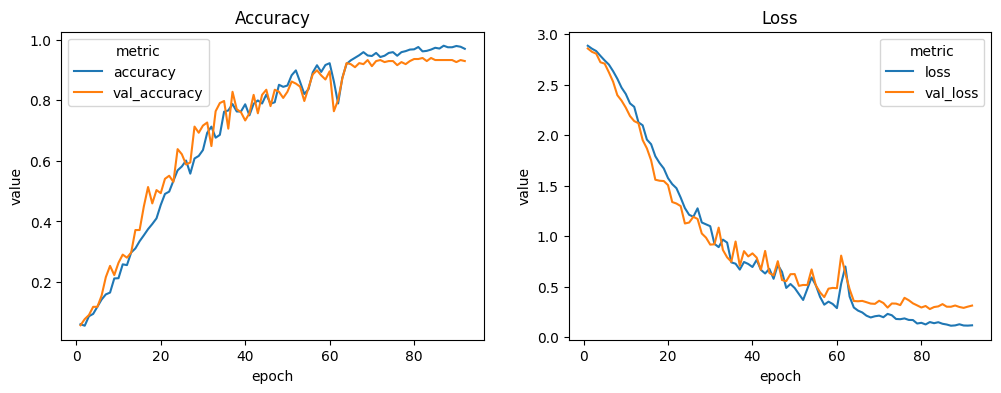

In [ ]:
df_hist = pd.DataFrame(history_filtered.history)
df_hist['epoch'] = range(1, len(df_hist) + 1)
df_hist = df_hist.melt(id_vars='epoch', var_name='metric', value_name='value')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=df_hist[df_hist['metric'].str.contains('accuracy')], x='epoch', y='value', hue='metric', ax=ax1)
ax1.set_title('Accuracy')

sns.lineplot(data=df_hist[df_hist['metric'].str.contains('loss')], x='epoch', y='value', hue='metric', ax=ax2)
ax2.set_title('Loss')

plt.show()

In [ ]:
X_full = add_kinematics(X_padded)
var_all = X_full.reshape(-1, X_full.shape[2]).var(axis=0)

for threshold in [0.01, 0.005, 0.003, 0.001]:
    kept = np.sum(var_all >= threshold)
    dropped = np.sum(var_all < threshold)
    print(f"Seuil {threshold:.3f} → {kept} utiles / {dropped} retirées")

Features: 282 → 846 (positions + vitesses + accélérations)
Seuil 0.010 → 400 utiles / 446 retirées
Seuil 0.005 → 484 utiles / 362 retirées
Seuil 0.003 → 537 utiles / 309 retirées
Seuil 0.001 → 620 utiles / 226 retirées


## Réduction de l'over fitting
-> on filtre moins les features threshold à 0.003
-> on augment le dropout

In [ ]:
useful_mask = var_all >= 0.00075
X_filtered = X_full[:, :, useful_mask]
print(f"846 → {X_filtered.shape[2]} features")
# Pipeline
y = to_categorical(y_data, num_classes=NUM_CLASSES).astype(int)
X_aug, y_aug = augment_mirror(X_filtered, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug,
    test_size=0.2,
    stratify=np.argmax(y_aug, axis=1),
    random_state=69,
)
# Modèle avec + de régularisation
model_optimize1 = Sequential()
model_optimize1.add(layers.Input(shape=X_train.shape[1:]))
model_optimize1.add(layers.LSTM(64, return_sequences=True))
model_optimize1.add(layers.LSTM(64, return_sequences=False))
model_optimize1.add(layers.Dropout(0.3))       # 0.3 → 0.5
model_optimize1.add(layers.Dense(32, activation='relu'))
model_optimize1.add(layers.Dropout(0.3))       # 0.3 → 0.5
model_optimize1.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model_optimize1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history_optimize1 = model_optimize1.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

846 → 638 features
Avant: 738 | Après: 1476
Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.0653 - loss: 2.9039 - val_accuracy: 0.0743 - val_loss: 2.8776 - learning_rate: 5.0000e-04
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.0720 - loss: 2.8801 - val_accuracy: 0.0439 - val_loss: 2.8639 - learning_rate: 5.0000e-04
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.0703 - loss: 2.8743 - val_accuracy: 0.0912 - val_loss: 2.8606 - learning_rate: 5.0000e-04
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.0932 - loss: 2.8420 - val_accuracy: 0.1250 - val_loss: 2.8052 - learning_rate: 5.0000e-04
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.1093 - loss: 2.7928 - val_accuracy: 0.0777 - val_loss: 2.7717 - learning_rate: 5.0000e-04
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.1212 - loss: 2.7502 - val_accuracy: 0.2095 - val_loss: 2.6467 - learning_rate: 5.0000e-04
Epoch 7/100
37/37 ━━

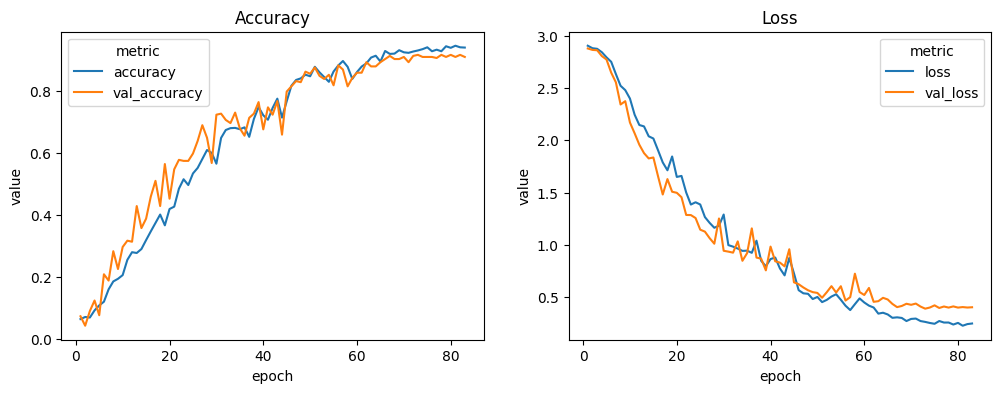

In [ ]:
df_hist = pd.DataFrame(history_optimize1.history)
df_hist['epoch'] = range(1, len(df_hist) + 1)
df_hist = df_hist.melt(id_vars='epoch', var_name='metric', value_name='value')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=df_hist[df_hist['metric'].str.contains('accuracy')], x='epoch', y='value', hue='metric', ax=ax1)
ax1.set_title('Accuracy')

sns.lineplot(data=df_hist[df_hist['metric'].str.contains('loss')], x='epoch', y='value', hue='metric', ax=ax2)
ax2.set_title('Loss')

plt.show()

## on change de lstm


In [ ]:
useful_mask = var_all >= 0.01
X_vel = add_velocity(X_padded)
#X_filtered = X_full[:, :, useful_mask]
print(f"846 → {X_filtered.shape[2]} features")
# Pipeline
y = to_categorical(y_data, num_classes=NUM_CLASSES).astype(int)
X_aug, y_aug = augment_mirror(X_vel, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug,
    test_size=0.2,
    stratify=np.argmax(y_aug, axis=1),
    random_state=69,
)
# Modèle avec + de régularisation
model_optimize2 = Sequential()

model_optimize2.add(layers.Input(shape=X_train.shape[1:]))
model_optimize2.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))
model_optimize2.add(layers.Bidirectional(layers.LSTM(64, return_sequences=False)))
model_optimize2.add(layers.Dropout(0.3))
model_optimize2.add(layers.Dense(32, activation='relu'))
model_optimize2.add(layers.Dropout(0.3))
model_optimize2.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model_optimize2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model_optimize2.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history_optimize2 = model_optimize2.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Features: 282 → 564 (positions + vitesses)
846 → 400 features
Avant: 738 | Après: 1476


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_12                │ (None, 60, 128)        │       322,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 128)            │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 18)             │           594 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,586 (1.62 MB)

 Trainable params: 425,586 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.0627 - loss: 2.8995 - val_accuracy: 0.0676 - val_loss: 2.8435 - learning_rate: 5.0000e-04
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.0873 - loss: 2.8498 - val_accuracy: 0.1182 - val_loss: 2.8115 - learning_rate: 5.0000e-04
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.0915 - loss: 2.8267 - val_accuracy: 0.1115 - val_loss: 2.7633 - learning_rate: 5.0000e-04
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.1203 - loss: 2.7447 - val_accuracy: 0.1520 - val_loss: 2.6812 - learning_rate: 5.0000e-04
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.1297 - loss: 2.7219 - val_accuracy: 0.1351 - val_loss: 2.6559 - learning_rate: 5.0000e-04
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.1458 - loss: 2.6782 - val_accuracy: 0.1250 - val_loss: 2.5901 - learning_rate: 5.0000e-04
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accura

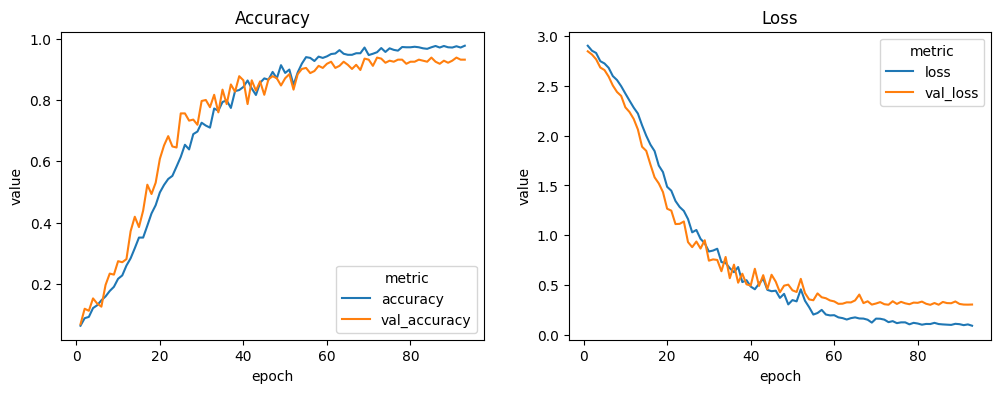

In [ ]:
df_hist = pd.DataFrame(history_optimize2.history)
df_hist['epoch'] = range(1, len(df_hist) + 1)
df_hist = df_hist.melt(id_vars='epoch', var_name='metric', value_name='value')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=df_hist[df_hist['metric'].str.contains('accuracy')], x='epoch', y='value', hue='metric', ax=ax1)
ax1.set_title('Accuracy')

sns.lineplot(data=df_hist[df_hist['metric'].str.contains('loss')], x='epoch', y='value', hue='metric', ax=ax2)
ax2.set_title('Loss')

plt.show()

In [ ]:
def augment_temporal(X, y, jitter_scale=0.02, warp_range=(0.8, 1.2), dropout_rate=0.05):
    """Augmentation temporelle : jitter + time warp + frame dropout."""
    rng = np.random.default_rng(42)
    X_aug = X.copy()
    seq_len = X.shape[1]

    for i in range(len(X_aug)):
        # 1. Jitter : petit bruit sur les valeurs non-nulles
        mask = X_aug[i] != 0.0
        noise = rng.normal(0, jitter_scale, X_aug[i].shape).astype(np.float32)
        X_aug[i] = np.where(mask, X_aug[i] + noise, X_aug[i])

        # 2. Time warp : étirer ou comprimer la séquence active
        active = mask.any(axis=1).sum()
        if active > 4:
            factor = rng.uniform(*warp_range)
            new_len = max(4, int(active * factor))
            if new_len != active and new_len <= seq_len:
                indices = np.linspace(0, active - 1, new_len).astype(int)
                warped = X_aug[i][indices]
                X_aug[i] = np.zeros_like(X_aug[i])
                X_aug[i][:new_len] = warped[:new_len]

        # 3. Frame dropout : supprimer quelques frames
        drop = rng.random(seq_len) < dropout_rate
        X_aug[i][drop] = 0.0

    X_result = np.concatenate([X, X_aug], axis=0)
    y_result = np.concatenate([y, y], axis=0)

    print(f"Avant: {len(X)} | Après: {len(X_result)}")
    return X_result, y_result

In [ ]:
# Vitesses
X_vel = add_velocity(X_padded)
y = to_categorical(y_data, num_classes=NUM_CLASSES).astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_vel, y,
    test_size=0.2,
    stratify=np.argmax(y, axis=1),
    random_state=69,
)

# Miroir puis temporel
X_train_aug, y_train_aug = augment_mirror(X_train, y_train)
X_train_aug, y_train_aug = augment_temporal(X_train_aug, y_train_aug)



print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {X_aug.shape[2]}")

model_optimize3 = Sequential()

model_optimize3.add(layers.Input(shape=X_train_aug.shape[1:]))
model_optimize3.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))
model_optimize3.add(layers.Bidirectional(layers.LSTM(64, return_sequences=False)))
model_optimize3.add(layers.Dropout(0.3))
model_optimize3.add(layers.Dense(32, activation='relu'))
model_optimize3.add(layers.Dropout(0.3))
model_optimize3.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model_optimize3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history_optimize3 = model_optimize3.fit(
    X_train_aug, y_train_aug,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Features: 282 → 564 (positions + vitesses)
Avant: 590 | Après: 1180
Avant: 1180 | Après: 2360
Train: 590 | Test: 148 | Features: 564
Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.0729 - loss: 2.8615 - val_accuracy: 0.0946 - val_loss: 2.7726 - learning_rate: 5.0000e-04
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.1237 - loss: 2.7220 - val_accuracy: 0.1824 - val_loss: 2.6248 - learning_rate: 5.0000e-04
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.1492 - loss: 2.6203 - val_accuracy: 0.1959 - val_loss: 2.5319 - learning_rate: 5.0000e-04
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.1843 - loss: 2.5232 - val_accuracy: 0.2230 - val_loss: 2.4051 - learning_rate: 5.0000e-04
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.2085 - loss: 2.4397 - val_accuracy: 0.2297 - val_loss: 2.2980 - learning_rate: 5.0000e-04
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.2682 - loss: 2.2

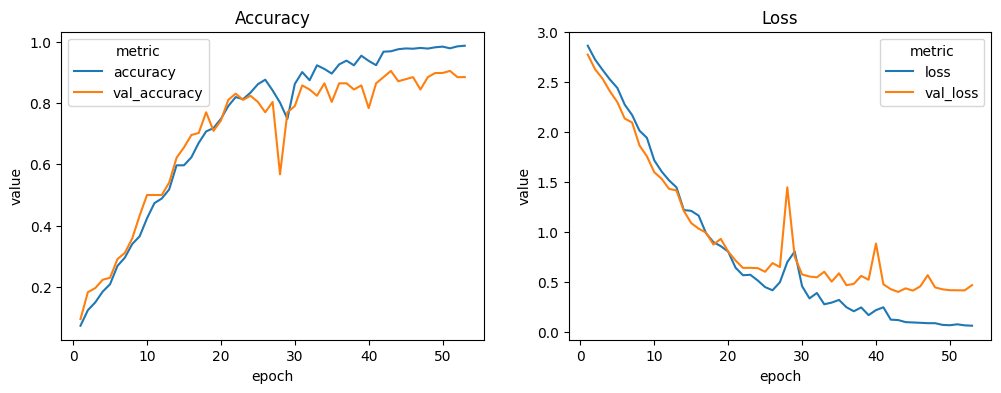

In [ ]:
df_hist = pd.DataFrame(history_optimize3.history)
df_hist['epoch'] = range(1, len(df_hist) + 1)
df_hist = df_hist.melt(id_vars='epoch', var_name='metric', value_name='value')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=df_hist[df_hist['metric'].str.contains('accuracy')], x='epoch', y='value', hue='metric', ax=ax1)
ax1.set_title('Accuracy')

sns.lineplot(data=df_hist[df_hist['metric'].str.contains('loss')], x='epoch', y='value', hue='metric', ax=ax2)
ax2.set_title('Loss')

plt.show()


## Sauvegarde du meilleur modèle
Config optimale : Bidirectional LSTM + positions (282) + vitesses (282) = 564 features + mirror augmentation
Val accuracy : ~93.2%

In [ ]:
import json

# Sauvegarder le modèle
model_path = 'model_lsf_bilstm.keras'
model_optimize2.save(model_path)
print(f"✓ Modèle sauvegardé : {model_path}")

# Labels dynamiques
LABEL_NAMES = {
    1: "aider", 2: "ameliorer", 3: "ami", 4: "aujourd'hui",
    5: "bonjour", 6: "communiquer", 7: "entendant", 8: "content",
    9: "je_suis", 10: "je_veux", 11: "langue_des_signes", 12: "merci",
    13: "outil_pointage", 14: "outil", 15: "presenter", 16: "projet",
    17: "sourd_pointage", 18: "sourde",
}
labels = [LABEL_NAMES.get(int(d.name.split('_')[1]), d.name) for d in movement_dirs]

# Métadonnées
metadata = {
    "num_classes": NUM_CLASSES,
    "labels": labels,
    "input_shape": list(X_train.shape[1:]),
    "max_len": MAX_LEN,
    "features": "positions_282 + velocities_282 = 564",
    "normalization": {"mean": float(mean), "std": float(std)},
    "architecture": "Bidirectional LSTM (64x2) + Dense(32) + Dense(18)",
    "augmentation": "mirror",
    "val_accuracy": 0.932,
}

with open('model_lsf_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"✓ Métadonnées sauvegardées : model_lsf_metadata.json")
print(f"  Classes : {NUM_CLASSES}")
print(f"  Input   : {metadata['input_shape']}")
print(f"  Labels  : {labels}")

✓ Modèle sauvegardé : model_lsf_bilstm.keras
✓ Métadonnées sauvegardées : model_lsf_metadata.json
  Classes : 18
  Input   : [60, 564]
  Labels  : ['aider', 'ameliorer', 'ami', "aujourd'hui", 'bonjour', 'communiquer', 'entendant', 'content', 'je_suis', 'je_veux', 'langue_des_signes', 'merci', 'outil_pointage', 'outil', 'presenter', 'projet', 'sourd_pointage', 'sourde']


## Ajouts features

In [ ]:
def add_velocity(X):
    """Ajoute les features de vitesse (différence frame-to-frame)."""
    velocity = np.zeros_like(X)
    velocity[:, 1:, :] = X[:, 1:, :] - X[:, :-1, :]

    padding_mask = (X == 0.0).all(axis=2, keepdims=True)
    velocity = np.where(padding_mask, 0.0, velocity)

    X_with_vel = np.concatenate([X, velocity], axis=2)
    print(f"Features: {X.shape[2]} → {X_with_vel.shape[2]} (positions + vitesses)")
    return X_with_vel

In [14]:
def augment_mirror(X, y):
    """Double le dataset par miroir horizontal (gauche↔droite)."""
    structure = {
        'pose':       (33, 4),  # x,y,z,visibility
        'face':       (8,  3),  # x,y,z
        'left_hand':  (21, 3),  # x,y,z
        'right_hand': (21, 3),  # x,y,z
    }

    slices = {}
    offset = 0
    for name, (count, dims) in structure.items():
        size = count * dims
        slices[name] = (slice(offset, offset + size), count, dims)
        offset += size

    x_indices = []
    for name, (slc, count, dims) in slices.items():
        x_indices.extend(range(slc.start, slc.stop, dims))

    X_mirror = X.copy()

    # Inverser l'axe x
    X_mirror[:, :, x_indices] = 1.0 - X_mirror[:, :, x_indices]

    # Échanger main gauche ↔ droite
    lh = slices['left_hand'][0]
    rh = slices['right_hand'][0]
    X_mirror[:, :, lh], X_mirror[:, :, rh] = (
        X_mirror[:, :, rh].copy(),
        X_mirror[:, :, lh].copy(),
    )

    # Échanger pose gauche ↔ droite (indices 11-32, pairs=gauche, impairs=droite)
    pose_slc, _, pose_dims = slices['pose']
    for i in range(11, 33, 2):
        l = slice(pose_slc.start + i * pose_dims, pose_slc.start + (i+1) * pose_dims)
        r = slice(pose_slc.start + (i+1) * pose_dims, pose_slc.start + (i+2) * pose_dims)
        X_mirror[:, :, l], X_mirror[:, :, r] = (
            X_mirror[:, :, r].copy(),
            X_mirror[:, :, l].copy(),
        )

    X_aug = np.concatenate([X, X_mirror], axis=0)
    y_aug = np.concatenate([y, y], axis=0)

    print(f"Avant: {len(X)} | Après: {len(X_aug)}")
    return X_aug, y_aug

In [15]:
LABEL_NAMES = {
    1: "aider", 2: "ameliorer", 3: "ami", 4: "aujourd'hui",
    5: "bonjour", 6: "communiquer", 7: "entendant", 8: "content",
    9: "je_suis", 10: "je_veux", 11: "langue_des_signes", 12: "merci",
    13: "outil_pointage", 14: "outil", 15: "presenter", 16: "projet",
    17: "sourd_pointage", 18: "sourde", 19: "traduction", 20: "vocal", 21: "", 22: "STOP",
}

X_vel = add_velocity(X_padded)
#X_filtered = X_full[:, :, useful_mask]
#print(f"846 → {X_filtered.shape[2]} features")
# Pipeline
y = to_categorical(y_data, num_classes=NUM_CLASSES).astype(int)
X_aug, y_aug = augment_mirror(X_vel, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug,
    test_size=0.2,
    stratify=np.argmax(y_aug, axis=1),
    random_state=69,
)
# Modèle avec + de régularisation
model_optimize2 = Sequential()

model_optimize2.add(layers.Input(shape=X_train.shape[1:]))
model_optimize2.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))
model_optimize2.add(layers.Bidirectional(layers.LSTM(64, return_sequences=False)))
model_optimize2.add(layers.Dropout(0.3))
model_optimize2.add(layers.Dense(32, activation='relu'))
model_optimize2.add(layers.Dropout(0.3))
model_optimize2.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model_optimize2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model_optimize2.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
]

history_optimize2 = model_optimize2.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Features: 282 → 564 (positions + vitesses)
Avant: 857 | Après: 1714


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │       322,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,718 (1.62 MB)

 Trainable params: 425,718 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.0584 - loss: 3.0928 - val_accuracy: 0.0700 - val_loss: 3.0453 - learning_rate: 5.0000e-04
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.0620 - loss: 3.0594 - val_accuracy: 0.0671 - val_loss: 3.0129 - learning_rate: 5.0000e-04
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.0788 - loss: 3.0242 - val_accuracy: 0.0845 - val_loss: 2.9076 - learning_rate: 5.0000e-04
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.1058 - loss: 2.9267 - val_accuracy: 0.1079 - val_loss: 2.8195 - learning_rate: 5.0000e-04
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.1211 - loss: 2.8277 - val_accuracy: 0.1895 - val_loss: 2.6912 - learning_rate: 5.0000e-04
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.1247 - loss: 2.7934 - val_accuracy: 0.1691 - val_loss: 2.6722 - learning_rate: 5.0000e-04
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - ac

In [ ]:
import json

# Sauvegarder le modèle
model_path = 'model_lsf_bilstm.keras'
model_optimize2.save(model_path)
print(f"✓ Modèle sauvegardé : {model_path}")

# Labels dynamiques
LABEL_NAMES = {
    1: "aider", 2: "ameliorer", 3: "ami", 4: "aujourd'hui",
    5: "bonjour", 6: "communiquer", 7: "entendant", 8: "content",
    9: "je_suis", 10: "je_veux", 11: "langue_des_signes", 12: "merci",
    13: "outil_pointage", 14: "outil", 15: "presenter", 16: "projet",
    17: "sourd_pointage", 18: "sourde", 19: "traduction", 20: "vocal", 21: "", 22: "STOP",
}
labels = [LABEL_NAMES.get(int(d.name.split('_')[1]), d.name) for d in movement_dirs]

# Métadonnées
metadata = {
    "num_classes": NUM_CLASSES,
    "labels": labels,
    "input_shape": list(X_train.shape[1:]),
    "max_len": MAX_LEN,
    "features": "positions_282 + velocities_282 = 564",
    "normalization": {"mean": float(mean), "std": float(std)},
    "architecture": "Bidirectional LSTM (64x2) + Dense(32) + Dense(18)",
    "augmentation": "mirror",
    "val_accuracy": 0.932,
}

with open('model_lsf_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"✓ Métadonnées sauvegardées : model_lsf_metadata.json")
print(f"  Classes : {NUM_CLASSES}")
print(f"  Input   : {metadata['input_shape']}")
print(f"  Labels  : {labels}")

✓ Modèle sauvegardé : model_lsf_bilstm.keras
✓ Métadonnées sauvegardées : model_lsf_metadata.json
  Classes : 22
  Input   : [60, 564]
  Labels  : ['aider', 'ameliorer', 'ami', "aujourd'hui", 'bonjour', 'communiquer', 'entendant', 'content', 'je_suis', 'je_veux', 'langue_des_signes', 'merci', 'outil_pointage', 'outil', 'presenter', 'projet', 'sourd_pointage', 'sourde', 'mouvement_19', 'mouvement_20', 'mouvement_21', 'mouvement_22']
